In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load synthetic v2 or fallback to v1
candidates = [
    Path("D:/btp-ml-cyber-roi/data/model_ready/synthetic_samples_ctgan_v2.csv"),
    Path("D:/btp-ml-cyber-roi/data/model_ready/synthetic_samples_ctgan.csv"),
]
DATA_SYN = next((p for p in candidates if p.exists()), None)
assert DATA_SYN is not None, "Synthetic dataset not found."

df = pd.read_csv(DATA_SYN)
print("Loaded:", DATA_SYN, "| shape:", df.shape)

# Unify naming if present
if "Canonical_Attack_Vector" in df.columns and "Attack_Vector" not in df.columns:
    df = df.rename(columns={"Canonical_Attack_Vector": "Attack_Vector"})

# Drop derived/leakage columns
DROP = {"Per_Record_Cost_USD", "Estimated_Financial_Impact_Million_USD"}
df = df.drop(columns=[c for c in DROP if c in df.columns], errors="ignore")

# Basic NA handling
for c in df.select_dtypes(include=[np.number]).columns:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
for c in df.select_dtypes(exclude=[np.number]).columns:
    df[c] = df[c].astype(str).replace({"nan": np.nan}).fillna(df[c].mode().iloc[0])

print("Nulls after clean:", int(df.isna().sum().sum()))
df.head(3)


Loaded: D:\btp-ml-cyber-roi\data\model_ready\synthetic_samples_ctgan_v2.csv | shape: (24200, 14)
Nulls after clean: 0


,Industry,Country,Year,Attack_Type,Data_Type,Records_Compromised,Employee_Count,Security_Budget_Million_USD,Financial_Impact_Million_USD,Recovery_Time_Days,Incident_Severity,Baseline_Industry_Cost_Million_USD
0,Banking,USA,2021.0,Phishing,pii_customer,20595.08,8799,12.7,45.4682,28,3.0,4.240
1,Banking,USA,2019.0,Phishing,pii_customer,255430.73,8845,12.3,92.0554,29,3.0,4.221
2,Banking,Russia,2016.0,Phishing,pii_customer,17486.67,9231,12.5,91.3661,44,3.0,4.208


In [2]:
# Ratios and normalized features
eps = 1e-9
if {"Security_Budget_Million_USD","Employee_Count"}.issubset(df.columns):
    df["Budget_per_Employee"] = df["Security_Budget_Million_USD"] / (df["Employee_Count"] + eps)

if {"Records_Compromised","Employee_Count"}.issubset(df.columns):
    df["Records_per_Employee"] = df["Records_Compromised"] / (df["Employee_Count"] + eps)

# Optional: impact per record (diagnostics only; NOT a feature to avoid leakage)
if {"Financial_Impact_Million_USD","Records_Compromised"}.issubset(df.columns):
    df["Impact_per_Record_diag"] = (
        df["Financial_Impact_Million_USD"] * 1_000_000 / (df["Records_Compromised"].clip(lower=1))
    )

# Winsorize heavy tails for stability of tree models
def winsorize(s, p=0.005):
    lo, hi = s.quantile([p, 1 - p])
    return s.clip(lo, hi)

for c in [
    "Records_Compromised","Employee_Count","Security_Budget_Million_USD",
    "Recovery_Time_Days","Baseline_Industry_Cost_Million_USD",
    "Budget_per_Employee","Records_per_Employee"
]:
    if c in df.columns:
        df[c] = winsorize(pd.to_numeric(df[c], errors="coerce"))


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

TARGET = "Financial_Impact_Million_USD"
assert TARGET in df.columns, "Target missing."

FEATURE_COLS = [
    "Industry","Country","Year",
    "Attack_Type","Data_Type",
    "Records_Compromised","Employee_Count",
    "Security_Budget_Million_USD","Recovery_Time_Days",
    "Incident_Severity","Baseline_Industry_Cost_Million_USD"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
y = df[TARGET].astype(float)

cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
if cat_cols:
    X_cat = enc.fit_transform(X[cat_cols].astype(str))
    X_cat = pd.DataFrame(X_cat, columns=cat_cols, index=X.index)
    X_final = pd.concat([X[num_cols].reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
else:
    X_final = X[num_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)
print("Features:", list(X_final.columns))
print("Train/Test:", X_train.shape, X_test.shape)


Features: ['Year', 'Records_Compromised', 'Employee_Count', 'Security_Budget_Million_USD', 'Recovery_Time_Days', 'Incident_Severity', 'Baseline_Industry_Cost_Million_USD', 'Industry', 'Country', 'Attack_Type', 'Data_Type']
Train/Test: (19360, 11) (4840, 11)


In [5]:
!pip install xgboost lightgbm catboost scikit-learn

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached catboost-1.2.8-cp310-cp310-win_amd64.whl.metadata (1.5 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Using cached catboost-1.2.8-cp310-cp310-win_amd64.whl (102.5 MB)

   ---------------------------------------- 0/2 [lightgbm]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------

In [4]:
TARGET_RAW = "Financial_Impact_Million_USD"
assert TARGET_RAW in df.columns, "Target missing."

# Log target to reduce skew
df["log_impact"] = np.log1p(df[TARGET_RAW].astype(float))
TARGET = "log_impact"

FEATURE_COLS = [
    "Industry","Country","Year",
    "Attack_Type","Data_Type",
    "Records_Compromised","Employee_Count",
    "Security_Budget_Million_USD","Recovery_Time_Days",
    "Incident_Severity","Baseline_Industry_Cost_Million_USD",
    "Budget_per_Employee","Records_per_Employee"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
y = df[TARGET].astype(float)

cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Features:", FEATURE_COLS)
print("Categoricals:", cat_cols)
print("Numericals:", num_cols)


Features: ['Industry', 'Country', 'Year', 'Attack_Type', 'Data_Type', 'Records_Compromised', 'Employee_Count', 'Security_Budget_Million_USD', 'Recovery_Time_Days', 'Incident_Severity', 'Baseline_Industry_Cost_Million_USD', 'Budget_per_Employee', 'Records_per_Employee']
Categoricals: ['Industry', 'Country', 'Attack_Type', 'Data_Type']
Numericals: ['Year', 'Records_Compromised', 'Employee_Count', 'Security_Budget_Million_USD', 'Recovery_Time_Days', 'Incident_Severity', 'Baseline_Industry_Cost_Million_USD', 'Budget_per_Employee', 'Records_per_Employee']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train/Test:", X_train.shape, X_test.shape)


Train/Test: (19360, 13) (4840, 13)


In [14]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

used = None
pred_log = None

try:
    # Train CatBoost with categorical features (no manual encoding)
    from catboost import CatBoostRegressor

    cat_idx = [X.columns.get_loc(c) for c in cat_cols]
    model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
    model.fit(X_train, y_train, cat_features=cat_idx, eval_set=(X_test, y_test), verbose=False)
    pred_log = model.predict(X_test)
    used = "CatBoostRegressor"

except Exception:
    # Fallback: encode categoricals + XGBoost
    from sklearn.preprocessing import OrdinalEncoder
    from xgboost import XGBRegressor

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X_train_enc = X_train.copy()
        X_test_enc  = X_test.copy()
        X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
        X_test_enc[cat_cols]  = enc.transform(X_test[cat_cols].astype(str))
    else:
        X_train_enc, X_test_enc = X_train, X_test

    model = XGBRegressor(
        n_estimators=900,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_enc, y_train)
    pred_log = model.predict(X_test_enc)
    used = "XGBRegressor"

# Evaluate back on original scale
pred = np.expm1(pred_log)
y_true = np.expm1(y_test.values)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))

print("Model:", used)
print("R2 (log space):", round(r2_score(y_test, pred_log), 3))
print("R2 (original):", round(r2_score(y_true, pred), 3))
print("MAE (M$):", round(mean_absolute_error(y_true, pred), 3))
print("MAPE:", round(mape(y_true, pred), 3))


Model: CatBoostRegressor
R2 (log space): 0.407
R2 (original): 0.395
MAE (M$): 18.745
MAPE: 0.81


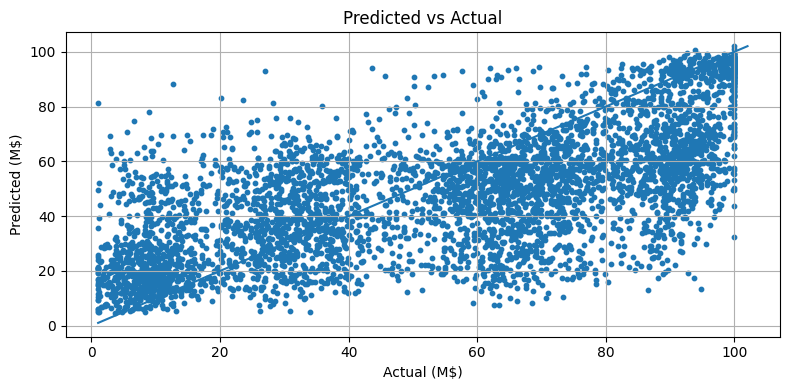

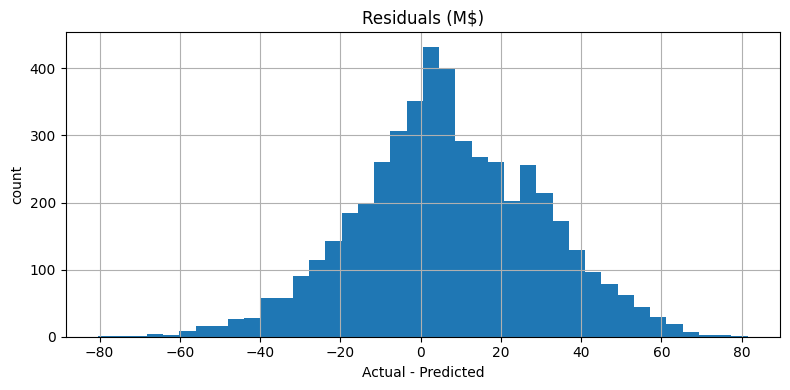

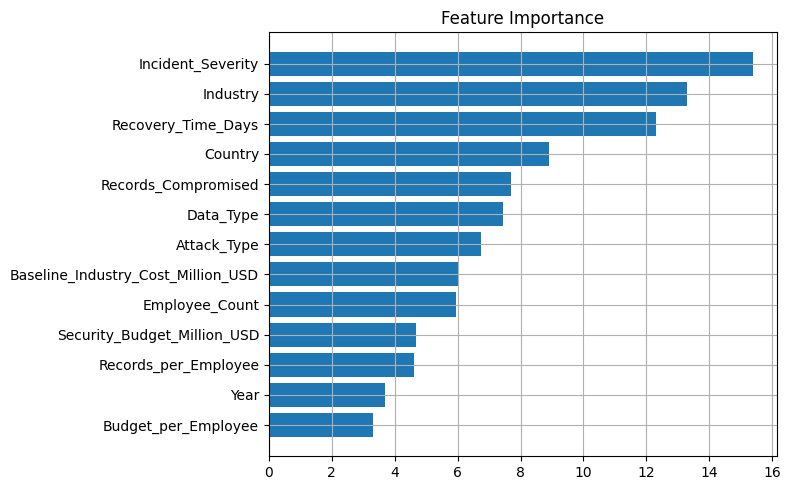

In [15]:
import matplotlib.pyplot as plt

# Predicted vs Actual (original scale)
plt.figure()
plt.scatter(y_true, pred, s=10)
mn, mx = float(min(y_true.min(), pred.min())), float(max(y_true.max(), pred.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Actual (M$)"); plt.ylabel("Predicted (M$)")
plt.title("Predicted vs Actual"); plt.tight_layout(); plt.show()

# Residuals
res = y_true - pred
plt.figure(); plt.hist(res, bins=40)
plt.title("Residuals (M$)"); plt.xlabel("Actual - Predicted"); plt.ylabel("count")
plt.tight_layout(); plt.show()

# Feature importance
try:
    # CatBoost
    if used == "CatBoostRegressor":
        importances = model.get_feature_importance(type="FeatureImportance")
        order = np.argsort(importances)[::-1]
        topk = min(15, len(order))
        names = np.array(X.columns)[order][:topk]
        vals = np.array(importances)[order][:topk]
    else:
        # XGBoost
        importances = getattr(model, "feature_importances_", None)
        if importances is None:
            raise RuntimeError("No feature_importances_ on model.")
        order = np.argsort(importances)[::-1]
        topk = min(15, len(order))
        names = np.array(X.columns)[order][:topk]
        vals = np.array(importances)[order][:topk]

    plt.figure(figsize=(8,5))
    plt.barh(range(topk), vals[::-1])
    plt.yticks(range(topk), names[::-1])
    plt.title("Feature Importance")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Skipping importance plot:", e)


In [17]:
import joblib
from pathlib import Path

out_dir = Path("D:/btp-ml-cyber-roi/data/models"); out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(model, out_dir / f"impact_regressor_{used}.pkl")
if used == "CatBoostRegressor":
    joblib.dump({"feature_cols": X.columns.tolist(), "cat_cols": cat_cols}, out_dir / "preproc_cat.pkl")
else:
    # saved only if XGB fallback path was used
    joblib.dump({"feature_cols": X.columns.tolist(), "cat_cols": cat_cols}, out_dir / "preproc_xgb.pkl")

print("Saved model to:", (out_dir / f"impact_regressor_{used}.pkl").as_posix())


Saved model to: D:/btp-ml-cyber-roi/data/models/impact_regressor_CatBoostRegressor.pkl


In [6]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

from catboost import CatBoostRegressor

# Train-test split (reuse existing X, y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
# --- Encode categoricals for ALL base models in the stack ---
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
if cat_cols:
    X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
    X_test_enc[cat_cols]  = enc.transform(X_test[cat_cols].astype(str))


In [ ]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from catboost import CatBoostRegressor

cb = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)  # no cat_features here, we already encoded

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

ridge = RidgeCV()

estimators = [("cat", cb), ("rf", rf), ("gb", gb)]
stack = StackingRegressor(estimators=estimators, final_estimator=ridge, n_jobs=-1)

stack.fit(X_train_enc, y_train)


StackingRegressor(estimators=[('cat',
                               <catboost.core.CatBoostRegressor object at 0x0000023DC5DAE740>),
                              ('rf',
                               RandomForestRegressor(max_depth=12,
                                                     min_samples_split=5,
                                                     n_estimators=400,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(learning_rate=0.05,
                                                         max_depth=5,
                                                         n_estimators=500,
                                                         random_state=42))],
                  final_estimator=RidgeCV(), n_jobs=-1)

d:\btp-ml-cyber-roi\.venv310\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model: Stacking Ensemble (CatBoost+RF+GB) [encoded]
R2 (log): 0.408
R2 (orig): 0.395
RMSE (M$): 23.863
MAE (M$): 18.954
MAPE: 0.819


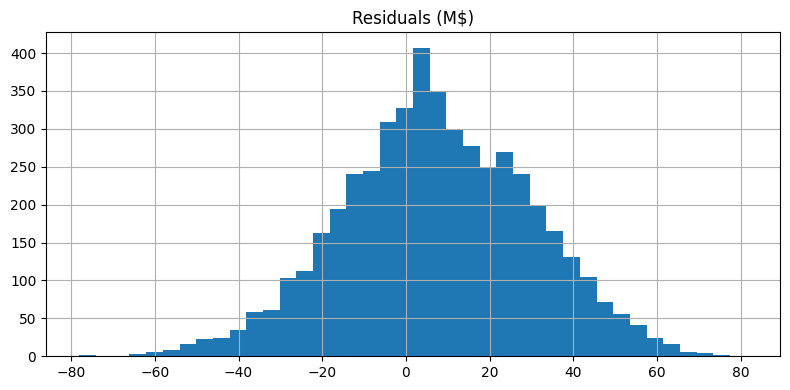

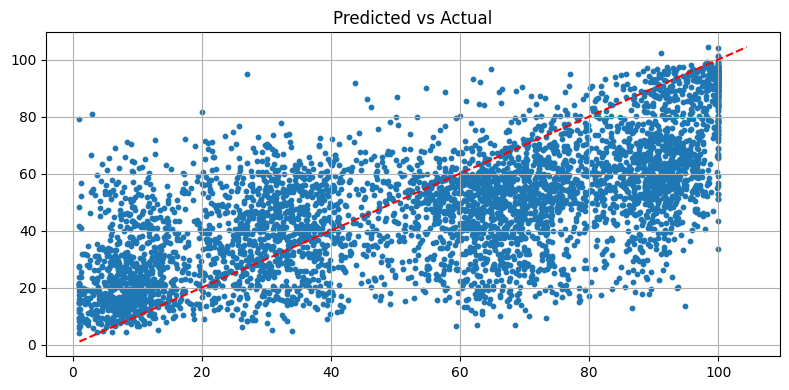

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

pred_log = stack.predict(X_test_enc)
pred_log = np.clip(pred_log, -20, None)
pred = np.expm1(pred_log)
y_true = np.expm1(y_test.values)
pred = np.maximum(pred, 0.0)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))

rmse = mean_squared_error(y_true, pred, squared=False)

print("Model: Stacking Ensemble (CatBoost+RF+GB) [encoded]")
print("R2 (log):", round(r2_score(y_test, pred_log), 3))
print("R2 (orig):", round(r2_score(y_true, pred), 3))
print("RMSE (M$):", round(rmse, 3))
print("MAE (M$):", round(mean_absolute_error(y_true, pred), 3))
print("MAPE:", round(mape(y_true, pred), 3))

# quick plots
plt.figure(); plt.hist(y_true - pred, bins=40); plt.title("Residuals (M$)"); plt.tight_layout(); plt.show()
plt.figure(); plt.scatter(y_true, pred, s=10); 
mn, mx = float(min(y_true.min(), pred.min())), float(max(y_true.max(), pred.max()))
plt.plot([mn,mx],[mn,mx],"r--"); plt.title("Predicted vs Actual"); plt.tight_layout(); plt.show()


In [25]:
from pathlib import Path
import joblib, json, time

out_dir = Path("D:/btp-ml-cyber-roi/data/models"); out_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d-%H%M%S")
name = f"stack_cb_rf_gb_{ts}"

# save model
joblib.dump(stack, out_dir / f"{name}.pkl")

# save preprocessing needed at inference
joblib.dump(
    {
        "encoder": enc,                 # OrdinalEncoder fitted earlier
        "feature_cols": X_train_enc.columns.tolist(),
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "target": "log_impact",         # model trained on log target
        "expm1": True                   # revert with np.expm1 at inference
    },
    out_dir / f"{name}_preproc.pkl"
)

# optional: model card
card = {
    "model_name": name,
    "type": "StackingRegressor(CatBoost+RF+GB)",
    "trained_on": ts,
    "metrics": {
        "r2_log": float(r2_score(y_test, stack.predict(X_test_enc))),
        "r2_original": float(r2_score(np.expm1(y_test), np.expm1(stack.predict(X_test_enc)))),
        "mae_musd": float(mean_absolute_error(np.expm1(y_test), np.maximum(np.expm1(stack.predict(X_test_enc)), 0))),
        "rmse_musd": float(mean_squared_error(np.expm1(y_test), np.maximum(np.expm1(stack.predict(X_test_enc)), 0), squared=False)),
        "mape": float(np.mean(np.abs((np.expm1(y_test) - np.maximum(np.expm1(stack.predict(X_test_enc)),0)) / np.maximum(np.expm1(y_test), 1e-8))))
    }
}
with open(out_dir / f"{name}_card.json", "w") as f:
    json.dump(card, f, indent=2)

print("Saved:", (out_dir / f"{name}.pkl").as_posix())
print("Saved:", (out_dir / f"{name}_preproc.pkl").as_posix())
print("Saved:", (out_dir / f"{name}_card.json").as_posix())


Saved: D:/btp-ml-cyber-roi/data/models/stack_cb_rf_gb_20251110-233316.pkl
Saved: D:/btp-ml-cyber-roi/data/models/stack_cb_rf_gb_20251110-233316_preproc.pkl
Saved: D:/btp-ml-cyber-roi/data/models/stack_cb_rf_gb_20251110-233316_card.json


d:\btp-ml-cyber-roi\.venv310\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [8]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# base learners (same)
cb = CatBoostRegressor(
    iterations=800, learning_rate=0.05, depth=8,
    loss_function="RMSE", random_seed=42, verbose=False
)  # encoded inputs, so no cat_features passed

rf = RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_split=5,
    random_state=42, n_jobs=-1
)

gb = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42
)

# meta-learner: XGB
meta_xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

estimators = [("cat", cb), ("rf", rf), ("gb", gb)]
stack_xgb = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_xgb,
    n_jobs=-1
)

stack_xgb.fit(X_train_enc, y_train)


StackingRegressor(estimators=[('cat',
                               <catboost.core.CatBoostRegressor object at 0x0000020BF1D03400>),
                              ('rf',
                               RandomForestRegressor(max_depth=12,
                                                     min_samples_split=5,
                                                     n_estimators=400,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(learning_rate=0.05,
                                                         max_depth=5,
                                                         n_estimators=500,
                                                         random_state=42))],
                  final_estimator=XGBRegressor(base_score=None, bo...
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=400, n_jobs=-1,
                                               num_parallel_tree=None, ...),
                  n_jobs=-1)

d:\btp-ml-cyber-roi\.venv310\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model: Stacking (CatBoost+RF+GB) → XGB meta [encoded]
R2 (log): 0.405
R2 (orig): 0.391
RMSE (M$): 23.936
MAE (M$): 18.919
MAPE: 0.821


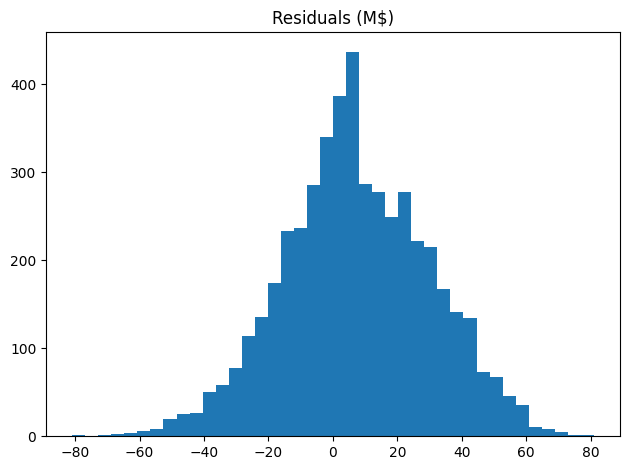

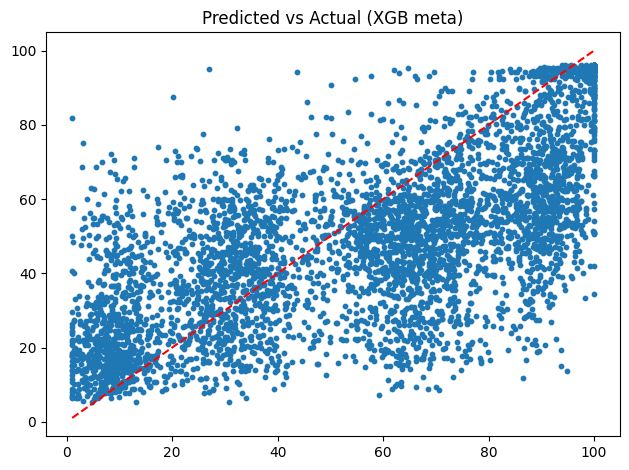

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np, matplotlib.pyplot as plt

pred_log = stack_xgb.predict(X_test_enc)
pred_log = np.clip(pred_log, -20, None)
pred = np.expm1(pred_log)
y_true = np.expm1(y_test.values)
pred = np.maximum(pred, 0.0)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))

rmse = mean_squared_error(y_true, pred, squared=False)

print("Model: Stacking (CatBoost+RF+GB) → XGB meta [encoded]")
print("R2 (log):", round(r2_score(y_test, pred_log), 3))
print("R2 (orig):", round(r2_score(y_true, pred), 3))
print("RMSE (M$):", round(rmse, 3))
print("MAE (M$):", round(mean_absolute_error(y_true, pred), 3))
print("MAPE:", round(mape(y_true, pred), 3))

plt.figure(); plt.hist(y_true - pred, bins=40)
plt.title("Residuals (M$)"); plt.tight_layout(); plt.show()

plt.figure(); plt.scatter(y_true, pred, s=10)
mn, mx = float(min(y_true.min(), pred.min())), float(max(y_true.max(), pred.max()))
plt.plot([mn, mx], [mn, mx], "r--")
plt.title("Predicted vs Actual (XGB meta)"); plt.tight_layout(); plt.show()

Model: Stacking (CatBoost+RF+GB) → MLP meta [encoded]
R2 (log): 0.399
R2 (orig): 0.328
RMSE (M$): 25.153
MAE (M$): 20.504
MAPE: 0.788


d:\btp-ml-cyber-roi\.venv310\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


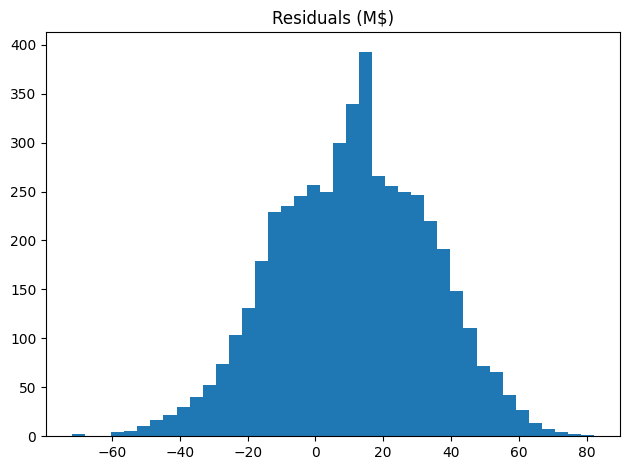

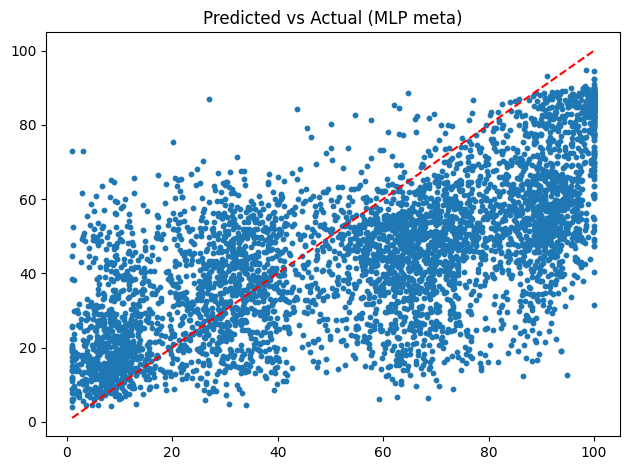

In [12]:
# --- Train + Evaluate: Stacking (CatBoost+RF+GB) with MLP meta-learner ---
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np, matplotlib.pyplot as plt

# base learners (same)
cb = CatBoostRegressor(
    iterations=800, learning_rate=0.05, depth=8,
    loss_function="RMSE", random_state=42, verbose=False
)
rf = RandomForestRegressor(n_estimators=400, max_depth=12, min_samples_split=5,
                           random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                               max_depth=5, random_state=42)

# meta-learner: MLP
meta_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    alpha=1e-3,         # L2
    batch_size=64,
    max_iter=2000,
    random_state=42,
    verbose=False
)

stack_mlp = StackingRegressor(
    estimators=[("cat", cb), ("rf", rf), ("gb", gb)],
    final_estimator=meta_mlp, n_jobs=-1
)
stack_mlp.fit(X_train_enc, y_train)

# evaluation (log → original scale)
pred_log = stack_mlp.predict(X_test_enc)
pred_log = np.clip(pred_log, -20, None)
pred = np.expm1(pred_log)
y_true = np.expm1(y_test.values)
pred = np.maximum(pred, 0.0)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))

rmse = mean_squared_error(y_true, pred, squared=False)

print("Model: Stacking (CatBoost+RF+GB) → MLP meta [encoded]")
print("R2 (log):", round(r2_score(y_test, pred_log), 3))
print("R2 (orig):", round(r2_score(y_true, pred), 3))
print("RMSE (M$):", round(rmse, 3))
print("MAE (M$):", round(mean_absolute_error(y_true, pred), 3))
print("MAPE:", round(mape(y_true, pred), 3))

plt.figure(); plt.hist(y_true - pred, bins=40)
plt.title("Residuals (M$)"); plt.tight_layout(); plt.show()

plt.figure(); plt.scatter(y_true, pred, s=10)
mn, mx = float(min(y_true.min(), pred.min())), float(max(y_true.max(), pred.max()))
plt.plot([mn, mx], [mn, mx], "r--")
plt.title("Predicted vs Actual (MLP meta)"); plt.tight_layout(); plt.show()
